In [63]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF/CUDA warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Force CPU, suppress CUDA errors
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"Base directory: {BASE_DIR}")


Base directory: /workspaces/ns-final-proj


In [64]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import math
import asgl
import re
import warnings
warnings.filterwarnings("ignore")
from tensorflow import keras


In [65]:
class Explanation:
    def __init__(self, current_sample, history_samples, model_path, original_score, feature_names, group_sizes, target):
        self.current_sample = current_sample
        self.history_samples = history_samples
        self.model_path = model_path
        self.original_score = original_score
        self.feature_names = feature_names
        self.group_size = group_sizes
        self.target = target
        self.relevant_history = []  # List to store relevant history samples
        self.delta = 0.001
        self.step = 10
        self.new_input = []
        self.weighted_samples = []
        self.coef = []


In [66]:
def search_proper_input(self):
    step = 0  # Current step
    for i in range(len(self.history_samples)):
        if step <= self.step:
            self.new_input = self.history_samples[-(i+1):]
            print(len(self.new_input))
            model = keras.models.load_model(self.model_path)  # Load the Keras model
            new_current_score = model.predict(self.new_input, batch_size=1)
            current_score = new_current_score[-1]
            print("searched current score", current_score)
            current_delta = abs(current_score - self.original_score)

            if current_delta <= self.delta:
                return self.new_input  # Found proper input
            step += 1
            i *= 2  # Double the value of i
        else:
            print("Cannot find the proper input within the max steps")
            return self.current_sample  # Cannot find proper input

    return None  # Proper input not found within max_steps

Explanation.search_proper_input = search_proper_input


In [67]:
def capture_relevant_history(self):
    """
    Capture the relevant history samples by running the model on current and historical samples.
    """
    model = keras.models.load_model(self.model_path)  # Load the Keras model
    model.summary()

    if self.target == 'lstm':
        current_prediction = model.predict(self.current_sample)
        current_score = current_prediction
    elif self.target == 'kitsune':
        current_prediction = model.predict(self.current_sample)
        current_score = np.mean(np.square(self.current_sample - current_prediction), axis=1)
    else:
        current_prediction = model.predict(self.current_sample, batch_size=1)
        current_score = current_prediction
        print("Current prediction score:", current_score)

    # Check the difference between current score and the original score
    difference = abs(current_score - self.original_score)
    print("original score:", self.original_score)
    print("difference:", difference)
    if difference > self.delta:
        print("The output is determined by current input and relevant history.")
        # approximate the history inputs here.
        self.new_input = self.history_samples
        self.new_input = self.search_proper_input()
    else:
        print("The output is determined by current input.")
        self.new_input = self.current_sample

Explanation.capture_relevant_history = capture_relevant_history


In [68]:
def weighted_sampling(self, num_samples):
    self.weighted_samples = np.array(self.weighted_samples)
    for idx, input_value in enumerate(self.new_input):
        distance = np.abs(idx + 1)  # Distance from the current input position
        # Determine the number of selected features based on the distance
        new_weight = distance / (distance + 1)
        print("weight:", new_weight)

        for i in range(num_samples):
            if self.target != 'kitsune':
                random_sample38 = np.zeros((1, 38))
                # Determine the number of selected features based on the distance
                num_selected = int(new_weight * 38 / 4)
                np.random.seed()  # Reset the random seed for each random sample

                # Select random indices for the features to include in the random sample
                selected_indices = np.random.choice(38, size=num_selected, replace=False)
                # Set the selected features to their corresponding values from the input
                input_value38 = input_value[:, :38]
                random_sample38 = random_sample38.reshape(1, 38)
                random_sample38[:, selected_indices] = input_value38[:, selected_indices]

                input_value_right3 = input_value[:, 38:41].reshape(1, 3)
                input_value_right70 = input_value[:, 41:111].reshape(1, 70)
                input_value_right11 = input_value[:, 111:].reshape(1, 11)
                random_sample = np.concatenate((random_sample38, input_value_right3, input_value_right70, input_value_right11), axis=1)

            else:
                random_sample = np.copy(input_value)  # Initialize the random sample with a copy of input_value

                distance = 1

                # Determine the number of selected features based on the distance
                num_selected = 50
                np.random.seed()  # Reset the random seed for each random sample

                # Select random indices for the features to include in the random sample
                selected_indices = np.random.choice(len(input_value), size=num_selected, replace=False)

                # Set the selected features to zero
                random_sample[selected_indices] = 0

            # Add the random sample to the list
            self.weighted_samples = np.append(self.weighted_samples, random_sample)

Explanation.weighted_sampling = weighted_sampling


In [69]:
def sparse_group_lasso(self):
    # Calculate the weights using sparse group lasso
    group_index = []
    for index, value in enumerate(self.group_size):
        group_index.extend([index + 1] * value)

    model = keras.models.load_model(self.model_path)  # Reload the Keras model
    if self.target == 'lstm':
        y_scores = model.predict(self.weighted_samples.reshape(-1, 1, len(self.feature_names)))
    elif self.target == 'kitsune':
        y_scores = model.predict(self.weighted_samples.reshape(-1, len(self.feature_names)))
        y_scores = np.mean(np.square(self.weighted_samples.reshape(-1, len(self.feature_names)) - y_scores), axis=1)
    else:
        y_scores = model.predict(self.weighted_samples.reshape(-1, 1, len(self.feature_names)), batch_size=1)

    x = self.weighted_samples.reshape(len(y_scores), -1)
    y = y_scores.reshape(len(y_scores))
    del model

    # Define parameters grid
    lambda1 = (10.0 ** np.arange(-3, 1.01, 0.6)).tolist()
    alpha = np.arange(0, 1, 0.2).tolist()
    power_weight = [0, 0.2, 1]

    # Define model parameters
    model = 'lm'
    penalization = 'sgl'
    tau = 0.5

    # Define cv class
    cross_validation_class = asgl.CV(model=model, penalization=penalization, lambda1=lambda1, alpha=alpha,
                           tau=0.5, parallel=True, weight_technique='pca_pct',
                           lasso_power_weight=power_weight, gl_power_weight=power_weight, variability_pct=0.85,
                           nfolds=5, error_type='QRE', random_state=42)

    # Compute error using k-fold cross validation
    error = cross_validation_class.cross_validation(x, y, group_index)

    # Obtain the mean error across different folds
    error = np.mean(error, axis=1)

    # Select the minimum error
    minimum_error_idx = np.argmin(error)

    # Select the parameters index associated to minimum error values
    optimal_parameters = cross_validation_class.retrieve_parameters_value(minimum_error_idx)

    # Define asgl class using optimal values
    asgl_model = asgl.ASGL(model=model, penalization=penalization, tau=tau,
                   intercept=cross_validation_class.intercept,
                   lambda1=optimal_parameters.get('lambda1'),
                   alpha=optimal_parameters.get('alpha'),
                   lasso_weights=optimal_parameters.get('lasso_weights'),
                   gl_weights=optimal_parameters.get('gl_weights'))

    # Split data into train / test
    train_idx, test_idx = asgl.train_test_split(nrows=x.shape[0], train_pct=0.7, random_state=1)

    # Solve the model
    asgl_model.fit(x=x[train_idx, :], y=y[train_idx], group_index=group_index)

    # Obtain betas
    self.coef = asgl_model.coef_

Explanation.sparse_group_lasso = sparse_group_lasso


In [70]:
def visualization(self, group_sizes, group_names, feature_names):
    # Get weights and group features
    weights = self.coef[0]
    # Normalize weights to range 0-1
    weights = (weights - np.min(weights)) / (np.max(weights) - np.min(weights))

    # Create color bar visualization
    plt.figure(figsize=(50, 3))
    cmap = plt.colormaps.get_cmap("coolwarm")
    colors = cmap(weights)
    start_index = 0
    total_features = sum(group_sizes)
    feature_index = 0

    # Iterate over groups
    for group_size, group_name in zip(group_sizes, group_names):
        group_weights = weights[start_index:start_index + group_size]
        group_colors = colors[start_index:start_index + group_size]
        group_labels = feature_names[feature_index:feature_index + group_size]

        # Plot color bars for features in the group
        for i, (weight, color, label) in enumerate(zip(group_weights, group_colors, group_labels)):
            plt.bar(feature_index + i, weight, color=color)
            # Connect the feature to its group name with a line
            plt.plot([feature_index + i, feature_index + group_size // 2], [weight, 1.3 * max(weights)], color='grey', linestyle='-')

        # Add group name below x-axis with adjusted spacing
        plt.text(feature_index + group_size // 2, 1.5, group_name, ha='center', va='top')

        feature_index += group_size
        start_index += group_size

    # Set x-axis ticks and labels
    plt.xticks(range(total_features), feature_names, rotation=45, ha='right')

    # Remove top, left, and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Hide y-axis ticks
    plt.yticks([])

    # Add color bar legend
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label="Importance Score", shrink=0.5, location='right', pad=0.00, anchor=(0, 0))
    plt.ylim(0, top=2)

    # Display the figure
    plt.show()

Explanation.visualization = visualization


In [71]:
num_samples = 100


# explain kitsune

# We use the false postives, and true postives  from kitsune to demostrate the explanation

# Location of the instances:

# 373907 true postive (1000000 for training)
# reconstruction_error 0.26677650458466096

# 456016 fasle negative
# reconstruction_error 0.14151900999030606

# 373081 false psitive
# 0.3029833795420598
# kitsune_selected_fp_rows = pd.DataFrame(X_test[kfp-10:kfp])

# threshold 0.20776055640832747


kitsune_model = os.path.join(BASE_DIR, "Models", "kitsune.h5")
kitsune_group_features = ["Group 1/Feature 1", "Group 1/Feature 2""Group 2/Feature 3", "Group 2/Feature 4","Group 2/Feature 5",]
kitsune_group_sizes = [15, 15,15,35,35]
kitsune_group_names = ["MAC-IP", "IP","Jitter","IPtoIP","Socket"]
kitsune_feature_names = [f'{i}' for i in range(1,116)]
# 5 types of streams
# packet sizes from a Mac-IP 3
# packet size from an IP 3
# Jitter froma an IP 3
# packet size between two IPs 7
# packet size between two Sockets 7
# Total 23 * 5 time windows

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)            │ (None, 115)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 115)            │        29,555 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,747 (553.70 KB)

 Trainable params: 141,747 (553.70 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
original score: 0.26677650458466096
difference: [0.00030295]
The output is determined by current input.
weight: 0.5


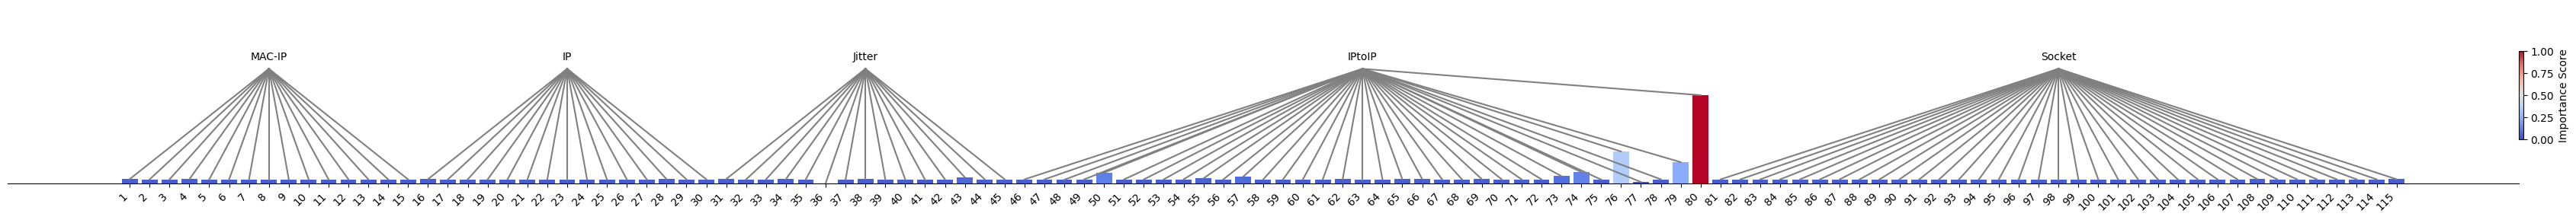

In [72]:
kitsune_tp_data  = pd.read_csv(os.path.join(BASE_DIR, "Data", "kitsune_selected_tp_rows.csv"))
kitsune_tp_current_sample = kitsune_tp_data.iloc[-1]
kitsune_tp_history_samples = kitsune_tp_data.iloc[:-1]
kitsune_tp_prediction_score = 0.26677650458466096
kitsune_tp_explanation = Explanation(kitsune_tp_current_sample.values.reshape(1,-1), kitsune_tp_history_samples, kitsune_model, kitsune_tp_prediction_score, kitsune_feature_names, kitsune_group_sizes, 'kitsune')
# Fix Keras H5 deserialization issue (e.g., 'keras.metrics.mse') by loading without compilation
if not hasattr(keras.models, "_original_load_model"):
    keras.models._original_load_model = keras.models.load_model

    def _safe_load_model(*args, **kwargs):
        kwargs.setdefault("compile", False)
        return keras.models._original_load_model(*args, **kwargs)

    keras.models.load_model = _safe_load_model

kitsune_tp_explanation.capture_relevant_history()
kitsune_tp_explanation.weighted_sampling(num_samples)
if hasattr(asgl, "CV"):
    kitsune_tp_explanation.sparse_group_lasso()
else:
    # Fallback when installed asgl package does not provide CV
    x_ws = kitsune_tp_explanation.weighted_samples.reshape(-1, len(kitsune_feature_names))
    model = keras.models.load_model(kitsune_model)  # already patched to compile=False above
    recon = model.predict(x_ws, batch_size=256, verbose=0)
    y_scores = np.mean(np.square(x_ws - recon), axis=1)

    # Simple ridge-style linear fit as surrogate importance
    reg = 1e-6
    xtx = x_ws.T @ x_ws + reg * np.eye(x_ws.shape[1])
    xty = x_ws.T @ y_scores
    beta = np.linalg.solve(xtx, xty)

    kitsune_tp_explanation.coef = [beta]
# Patch visualization to explicitly attach colorbar to an Axes
def _visualization_fixed(self, group_sizes, group_names, feature_names):
    weights = np.array(self.coef[0], dtype=float)

    w_min, w_max = np.min(weights), np.max(weights)
    if w_max > w_min:
        weights = (weights - w_min) / (w_max - w_min)
    else:
        weights = np.zeros_like(weights)

    fig, ax = plt.subplots(figsize=(50, 3))
    cmap = plt.colormaps.get_cmap("coolwarm")
    colors = cmap(weights)

    start_index = 0
    total_features = sum(group_sizes)
    feature_index = 0

    for group_size, group_name in zip(group_sizes, group_names):
        group_weights = weights[start_index:start_index + group_size]
        group_colors = colors[start_index:start_index + group_size]
        group_labels = feature_names[feature_index:feature_index + group_size]

        for i, (weight, color, _) in enumerate(zip(group_weights, group_colors, group_labels)):
            ax.bar(feature_index + i, weight, color=color)
            ax.plot(
                [feature_index + i, feature_index + group_size // 2],
                [weight, 1.3 * (np.max(weights) if np.max(weights) > 0 else 1)],
                color="grey",
                linestyle="-"
            )

        ax.text(feature_index + group_size // 2, 1.5, group_name, ha="center", va="top")
        feature_index += group_size
        start_index += group_size

    ax.set_xticks(range(total_features))
    ax.set_xticklabels(feature_names, rotation=45, ha="right")
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_yticks([])
    ax.set_ylim(0, 2)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Importance Score", shrink=0.5, location="right", pad=0.00)

    plt.show()

Explanation.visualization = _visualization_fixed

kitsune_tp_explanation.visualization(kitsune_group_sizes, kitsune_group_names, kitsune_feature_names)

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)            │ (None, 115)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 115)            │        29,555 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,747 (553.70 KB)

 Trainable params: 141,747 (553.70 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
original score: 0.14151900999030606
difference: [4.17099148e-05]
The output is determined by current input.
weight: 0.5


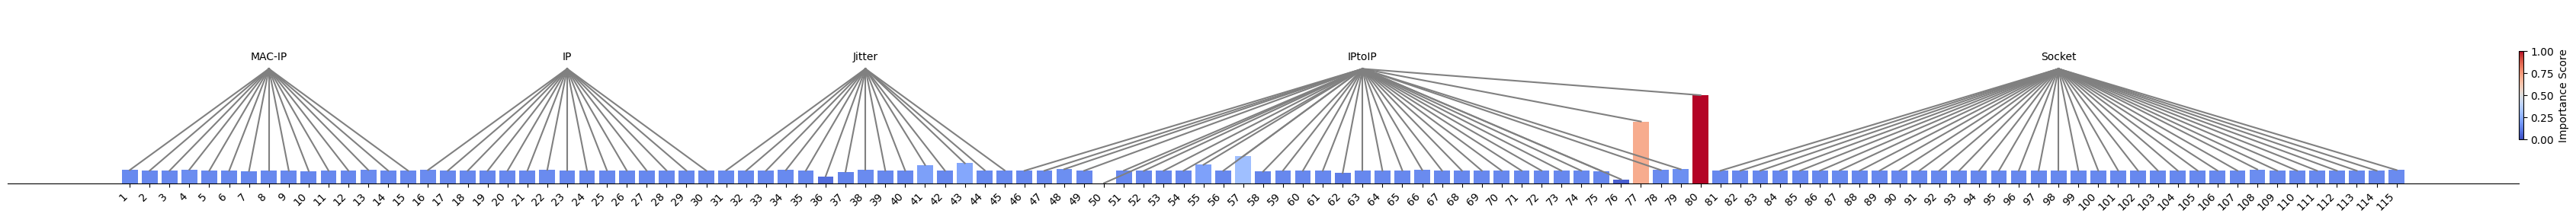

In [73]:
kitsune_fn_data  = pd.read_csv(os.path.join(BASE_DIR, "Data", "kitsune_selected_fn_rows.csv"))
kitsune_fn_current_sample = kitsune_fn_data.iloc[-1]
kitsune_fn_history_samples = kitsune_fn_data
kitsune_fn_prediction_score = 0.14151900999030606
kitsune_fn_explanation = Explanation(kitsune_fn_current_sample.values.reshape(1,-1), kitsune_fn_history_samples, kitsune_model, kitsune_fn_prediction_score, kitsune_feature_names, kitsune_group_sizes, 'kitsune')
kitsune_fn_explanation.capture_relevant_history()
kitsune_fn_explanation.weighted_sampling(num_samples)

if hasattr(asgl, "CV"):
	kitsune_fn_explanation.sparse_group_lasso()
else:
	# Fallback when installed asgl package does not provide CV
	fn_x_ws = kitsune_fn_explanation.weighted_samples.reshape(-1, len(kitsune_feature_names))
	fn_model = keras.models.load_model(kitsune_model)
	fn_recon = fn_model.predict(fn_x_ws, batch_size=256, verbose=0)
	fn_y_scores = np.mean(np.square(fn_x_ws - fn_recon), axis=1)

	# Simple ridge-style linear fit as surrogate importance
	fn_reg = 1e-6
	fn_xtx = fn_x_ws.T @ fn_x_ws + fn_reg * np.eye(fn_x_ws.shape[1])
	fn_xty = fn_x_ws.T @ fn_y_scores
	fn_beta = np.linalg.solve(fn_xtx, fn_xty)

	kitsune_fn_explanation.coef = [fn_beta]

kitsune_fn_explanation.visualization(kitsune_group_sizes, kitsune_group_names, kitsune_feature_names)

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)            │ (None, 115)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 115)            │        29,555 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,747 (553.70 KB)

 Trainable params: 141,747 (553.70 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
original score: 0.3029833795420598
difference: [0.0001722]
The output is determined by current input.
weight: 0.5


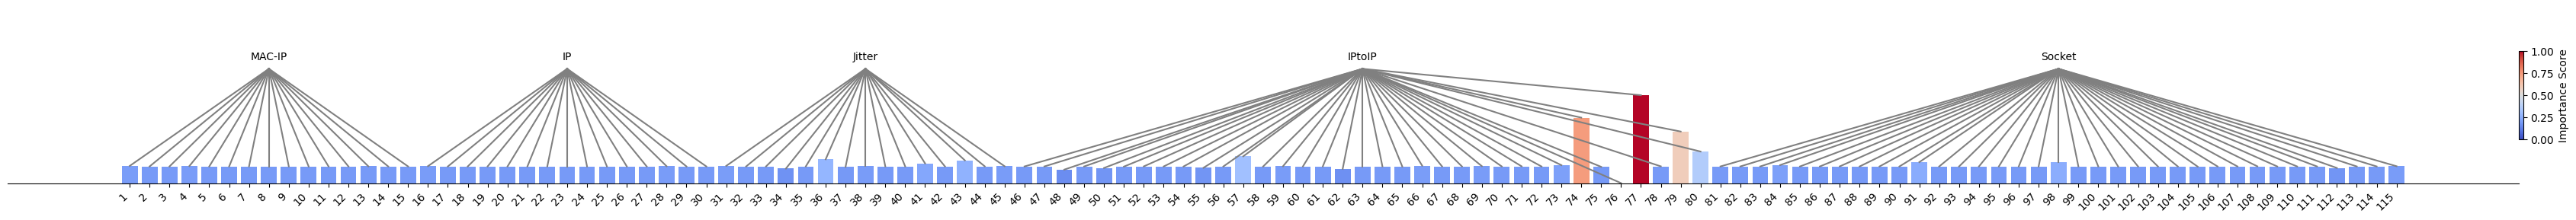

In [74]:
kitsune_fp_data  = pd.read_csv(os.path.join(BASE_DIR, "Data", "kitsune_selected_fp_rows.csv"))
kitsune_fp_current_sample = kitsune_fp_data.iloc[-1]
kitsune_fp_history_samples = kitsune_fp_data
kitsune_fp_prediction_score = 0.3029833795420598
kitsune_fp_explanation = Explanation(kitsune_fp_current_sample.values.reshape(1,-1), kitsune_fp_history_samples, kitsune_model, kitsune_fp_prediction_score, kitsune_feature_names, kitsune_group_sizes, 'kitsune')
kitsune_fp_explanation.capture_relevant_history()
kitsune_fp_explanation.weighted_sampling(num_samples)
if hasattr(asgl, "CV"):
    kitsune_fp_explanation.sparse_group_lasso()
else:
    # Fallback when installed asgl package does not provide CV
    fp_x_ws = kitsune_fp_explanation.weighted_samples.reshape(-1, len(kitsune_feature_names))
    fp_model = keras.models.load_model(kitsune_model)
    fp_recon = fp_model.predict(fp_x_ws, batch_size=256, verbose=0)
    fp_y_scores = np.mean(np.square(fp_x_ws - fp_recon), axis=1)

    # Simple ridge-style linear fit as surrogate importance
    fp_reg = 1e-6
    fp_xtx = fp_x_ws.T @ fp_x_ws + fp_reg * np.eye(fp_x_ws.shape[1])
    fp_xty = fp_x_ws.T @ fp_y_scores
    fp_beta = np.linalg.solve(fp_xtx, fp_xty)

    kitsune_fp_explanation.coef = [fp_beta]
kitsune_fp_explanation.visualization(kitsune_group_sizes, kitsune_group_names, kitsune_feature_names)

In [75]:
# explain RNN-IDS (stateless)
# We use the false postives, and false negatives  from RNN-IDS to demostrate the explanation

# Location of the instances:

# 571  false postive  tcp http SF
# predicted_probabilities[571]  array([0.7116914], dtype=float32)

# 21930 false negatives warezmaster
# predicted_probabilities[21930] array([0.44356757], dtype=float32)


import pandas as pd
kdd_model = os.path.join(BASE_DIR, "Models", "lstm_model.h5")
kdd_feature_names = np.load(os.path.join(BASE_DIR, "Data", "kdd_after_features.npy"))
kdd_feature_names =kdd_feature_names[kdd_feature_names != 'Class']
kdd_group_sizes = [1, 2, 1, 1, 1, 1, 2, 1, 3, 3,1,2,1,1,4,2,2,5,4,3,70,11 ]
kdd_group_names = [f'g{i}' for i in range(1,len(kdd_group_sizes)+1)]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        34,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,651 (135.36 KB)

 Trainable params: 34,651 (135.36 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
original score: 0.44356757
difference: [[5.9604645e-08]]
The output is determined by current input.
weight: 0.5


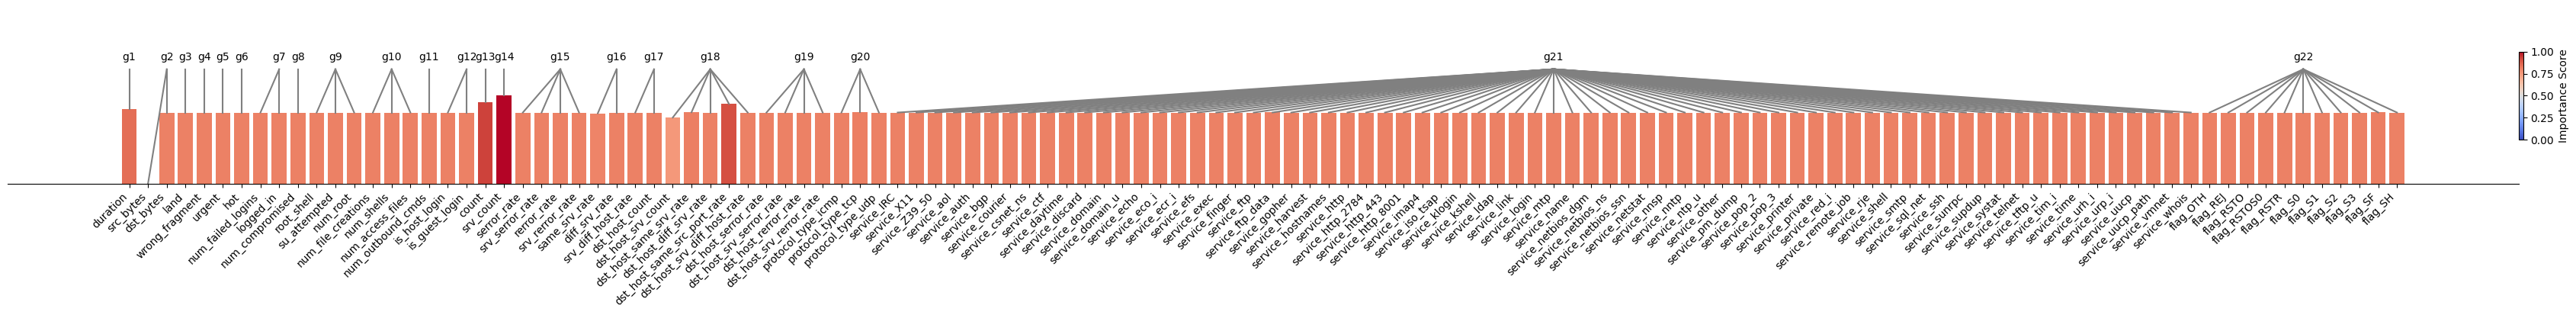

In [76]:
kdd_fn_data  = pd.read_csv(os.path.join(BASE_DIR, "Data", "kdd_selected_fn_rows_122.csv"))
kdd_fn_feature_data = kdd_fn_data.iloc[:,1 :]
kdd_fn_current_sample = kdd_fn_feature_data.iloc[-1]
kdd_fn_current_sample = kdd_fn_current_sample.values.reshape(1,1,-1)
kdd_fn_history_samples = kdd_fn_feature_data
kdd_fn_history_samples = kdd_fn_history_samples.values.reshape(len(kdd_fn_history_samples),1,-1)
kdd_fn_prediction_score = 0.44356757
if "kdd_model" not in globals():
    kdd_model = os.path.join(BASE_DIR, "Models", "lstm_model.h5")

if "kdd_feature_names" not in globals():
    kdd_feature_names = np.load(os.path.join(BASE_DIR, "Data", "kdd_after_features.npy"))
    kdd_feature_names = kdd_feature_names[kdd_feature_names != "Class"]

if "kdd_group_sizes" not in globals():
    kdd_group_sizes = [1, 2, 1, 1, 1, 1, 2, 1, 3, 3, 1, 2, 1, 1, 4, 2, 2, 5, 4, 3, 70, 11]

if "kdd_group_names" not in globals():
    kdd_group_names = [f"g{i}" for i in range(1, len(kdd_group_sizes) + 1)]

kdd_fn_explanation = Explanation(
    kdd_fn_current_sample,
    kdd_fn_history_samples,
    kdd_model,
    kdd_fn_prediction_score,
    kdd_feature_names,
    kdd_group_sizes,
    "lstm",
)
# Keras 3 compatibility patch for legacy H5 models that include `time_major` in LSTM config
if not hasattr(keras.models, "_original_load_model"):
    keras.models._original_load_model = keras.models.load_model

def _safe_load_model(*args, **kwargs):
    kwargs.setdefault("compile", False)
    try:
        return keras.models._original_load_model(*args, **kwargs)
    except ValueError as e:
        if "Unrecognized keyword arguments passed to LSTM" in str(e) and "time_major" in str(e):
            if not hasattr(keras.layers.LSTM, "_original_from_config"):
                keras.layers.LSTM._original_from_config = keras.layers.LSTM.from_config

                @classmethod
                def _lstm_from_config(cls, config):
                    config = dict(config)
                    config.pop("time_major", None)
                    return cls._original_from_config(config)

                keras.layers.LSTM.from_config = _lstm_from_config
            return keras.models._original_load_model(*args, **kwargs)
        raise

keras.models.load_model = _safe_load_model

kdd_fn_explanation.capture_relevant_history()
kdd_fn_explanation.weighted_sampling(num_samples)
if hasattr(asgl, "CV"):
    kdd_fn_explanation.sparse_group_lasso()
else:
    fn_x_ws = kdd_fn_explanation.weighted_samples.reshape(-1, len(kdd_feature_names))
    fn_model = keras.models.load_model(kdd_model)
    fn_y_scores = fn_model.predict(fn_x_ws.reshape(-1, 1, len(kdd_feature_names)), batch_size=1, verbose=0)
    fn_y_scores = fn_y_scores.reshape(-1)

    fn_reg = 1e-6
    fn_xtx = fn_x_ws.T @ fn_x_ws + fn_reg * np.eye(fn_x_ws.shape[1])
    fn_xty = fn_x_ws.T @ fn_y_scores
    fn_beta = np.linalg.solve(fn_xtx, fn_xty)

    kdd_fn_explanation.coef = [fn_beta]
kdd_fn_explanation.visualization(kdd_group_sizes, kdd_group_names, kdd_feature_names)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        34,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,651 (135.36 KB)

 Trainable params: 34,651 (135.36 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
original score: 0.7116914
difference: [[5.9604645e-08]]
The output is determined by current input.
weight: 0.5


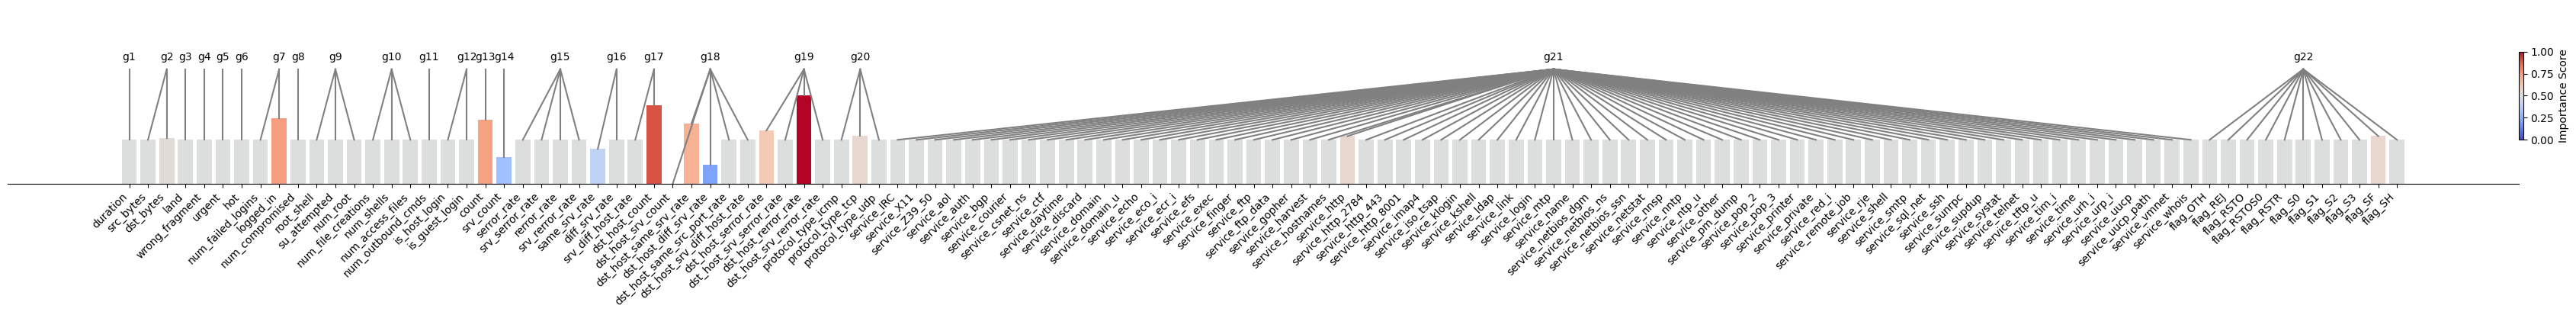

In [77]:
kdd_fp_data  = pd.read_csv(os.path.join(BASE_DIR, "Data", "kdd_selected_fp_rows_122.csv"))
kdd_fp_feature_data = kdd_fp_data.iloc[:,1 :]
kdd_fp_current_sample = kdd_fp_feature_data.iloc[-1]
kdd_fp_current_sample = kdd_fp_current_sample.values.reshape(1,1,-1)
kdd_fp_history_samples = kdd_fp_feature_data
kdd_fp_history_samples = kdd_fp_history_samples.values.reshape(len(kdd_fp_history_samples),1,-1)
kdd_fp_prediction_score = 0.7116914
kdd_fp_explanation = Explanation(kdd_fp_current_sample, kdd_fp_history_samples, kdd_model, kdd_fp_prediction_score, kdd_feature_names, kdd_group_sizes,'lstm')
kdd_fp_explanation.capture_relevant_history()
kdd_fp_explanation.weighted_sampling(num_samples)
if hasattr(asgl, "CV"):
    kdd_fp_explanation.sparse_group_lasso()
else:
    # Fallback when installed asgl package does not provide CV
    fp_x_ws = kdd_fp_explanation.weighted_samples.reshape(-1, len(kdd_feature_names))
    fp_model = keras.models.load_model(kdd_model)
    fp_y_scores = fp_model.predict(
        fp_x_ws.reshape(-1, 1, len(kdd_feature_names)),
        batch_size=1,
        verbose=0,
    ).reshape(-1)

    # Simple ridge-style linear surrogate for feature importance
    fp_reg = 1e-6
    fp_xtx = fp_x_ws.T @ fp_x_ws + fp_reg * np.eye(fp_x_ws.shape[1])
    fp_xty = fp_x_ws.T @ fp_y_scores
    fp_beta = np.linalg.solve(fp_xtx, fp_xty)

    kdd_fp_explanation.coef = [fp_beta]
kdd_fp_explanation.visualization(kdd_group_sizes, kdd_group_names, kdd_feature_names)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (1, 1, 50)             │        34,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 1, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, 10)                │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 10)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,051 (144.73 KB)

 Trainable params: 37,051 (144.73 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
Current prediction score: [[0.93549025]]
original score: 0.92638266
difference: [[0.00910759]]
The output is determined by current input and relevant history.
1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
searched current score [0.93549025]
2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
searched current score [0.5284182]
3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
searched current score [0.87616634]
4
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
searched current score [0.9263676]
weight: 0.5
weight: 0.6666666666666666
weight: 0.75
weight: 0.8


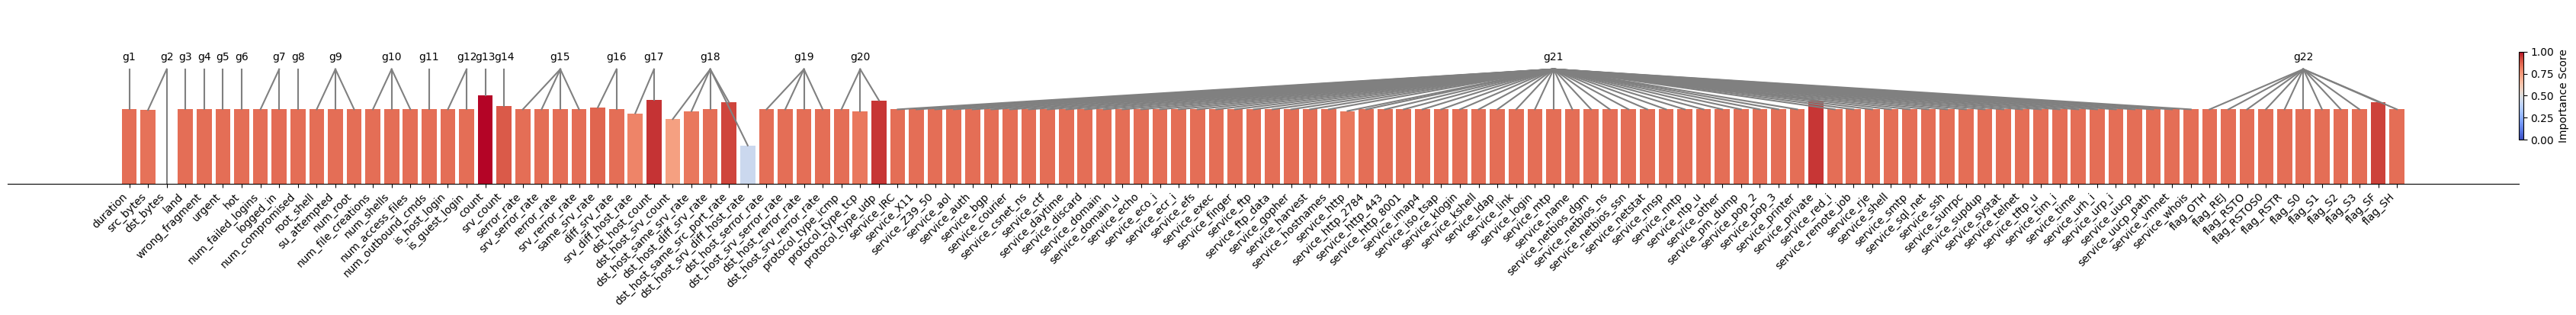

In [78]:
# explain stateful lstm
# 19114 fale positive
# predicted_probabilities[19114] array([0.92638266], dtype=float32)
# 19114	0	udp	private	SF	54	51	0

kdd_history_model = os.path.join(BASE_DIR, "Models", "lstm_history_model.h5")

kdd_history_fp_data  = pd.read_csv(os.path.join(BASE_DIR, "Data", "kdd_history_selected_fp_rows_122.csv"))
kdd_history_fp_feature_data = kdd_history_fp_data.iloc[:,1 :]
kdd_history_fp_current_sample = kdd_history_fp_feature_data.iloc[-1]
kdd_history_fp_current_sample = kdd_history_fp_current_sample.values.reshape(1,1,-1)
kdd_history_fp_history_samples = kdd_history_fp_feature_data
kdd_history_fp_history_samples = kdd_history_fp_history_samples.values.reshape(len(kdd_history_fp_history_samples),1,-1)
kdd_history_fp_prediction_score = 0.92638266
kdd_history_fp_explanation = Explanation(kdd_history_fp_current_sample, kdd_history_fp_history_samples, kdd_history_model, kdd_history_fp_prediction_score, kdd_feature_names, kdd_group_sizes,'lstmHistory')
kdd_history_fp_explanation.capture_relevant_history()
kdd_history_fp_explanation.weighted_sampling(num_samples)

if hasattr(asgl, "CV"):
	kdd_history_fp_explanation.sparse_group_lasso()
else:
	# Fallback when installed asgl package does not provide CV
	hist_x_ws = kdd_history_fp_explanation.weighted_samples.reshape(-1, len(kdd_feature_names))
	hist_model = keras.models.load_model(kdd_history_model)
	hist_y_scores = hist_model.predict(
		hist_x_ws.reshape(-1, 1, len(kdd_feature_names)),
		batch_size=1,
		verbose=0,
	).reshape(-1)

	# Simple ridge-style linear surrogate for feature importance
	hist_reg = 1e-6
	hist_xtx = hist_x_ws.T @ hist_x_ws + hist_reg * np.eye(hist_x_ws.shape[1])
	hist_xty = hist_x_ws.T @ hist_y_scores
	hist_beta = np.linalg.solve(hist_xtx, hist_xty)

	kdd_history_fp_explanation.coef = [hist_beta]

kdd_history_fp_explanation.visualization(kdd_group_sizes, kdd_group_names, kdd_feature_names)